In [52]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array

import config_dl

## Esquema de trabajo

dataset.csv
        │
        ▼
Pandas DataFrame
        │
        ▼
LabelEncoder
        │
        ▼
Train/Test Split
        │
        ▼
Guardar train.csv y test.csv   ← reutilizable
        │
        ▼
Leer imágenes (una vez)
        │
        ▼
Redimensionar
        │
        ▼
Normalizar
        │
        ▼
X_train
y_train
X_test
y_test
        │
        ▼
Entrenar CNN

In [3]:
df = pd.read_csv(config_dl.DATASET_CSV)
df_copia=df.copy()

In [4]:
#eliminamos valores conflictivso
lista_imagenes_no_validas_corregidas=["Apple/.DS_Store","Guava/.DS_Store"]
df_copia=df_copia[~df_copia["0"].isin(lista_imagenes_no_validas_corregidas)]


In [5]:
#codificamos frutas

label_encoder = LabelEncoder()

df_copia["label_encoded"] = label_encoder.fit_transform(df_copia["fruta"])

In [6]:
class_names = label_encoder.classes_

NUM_CLASSES = len(class_names)

In [7]:
train_df, test_df = train_test_split(

    df_copia,

    test_size=0.30,

    stratify=df_copia["label_encoded"],

    random_state=config_dl.RANDOM_STATE

)

In [8]:
#guardamos los df de train y test

train_df.to_csv(
    "train_dataset.csv",
    index=False
)

test_df.to_csv(
    "test_dataset.csv",
    index=False
)

In [80]:
#comprobamos los df
print(type(train_df))

print(train_df.columns)

print(train_df.head())

<class 'pandas.DataFrame'>
Index(['Unnamed: 0', '0', 'fruta', 'percent', 'label_encoded'], dtype='str')
       Unnamed: 0                                             0      fruta  \
7491         7491  Apple/Total Number of Apples/Apple 01463.png      Apple   
55445       55445                           Peach/Peach0092.png      Peach   
48975       48975                 muskmelon/Muskmelon 00931.png  muskmelon   
27743       27743      Guava/Guava total/Guava。2200 resized.png      Guava   
54259       54259                         Peach/Peach001990.png      Peach   

         percent  label_encoded  
7491   15.855197              0  
55445   3.726382              7  
48975   2.945387             14  
27743  27.921645              3  
54259   3.726382              7  


In [10]:
#creamos la funcion de procesamiento de imagen para X_train
def load_and_preprocess_image(image_path):
    """
    Carga una imagen desde disco y la prepara para la CNN.
    """

    # Leer imagen
    imagen = load_img(
        image_path,
        target_size=config_dl.IMAGE_SIZE
    )

    # Convertir a array de NumPy
    imagen = img_to_array(imagen)

    # Normalizar
    imagen = imagen.astype("float32") / 255.0

    return imagen

In [11]:
ruta = "../../../../archive/" + train_df.iloc[0]["0"]

print(ruta)

imagen = load_and_preprocess_image(ruta)

print(imagen.shape)

../../../../archive/Apple/Total Number of Apples/Apple 01463.png
(224, 224, 3)


In [17]:
print(type(train_paths))

<class 'pandas.Series'>


In [18]:
print(train_paths.iloc[0])

../../../../archive/Apple/Total Number of Apples/Apple 01463.png


In [19]:
print(train_paths.to_numpy()[0])

../../../../archive/Apple/Total Number of Apples/Apple 01463.png


In [ ]:
X_train = []
y_train = []

for _, fila in train_df.iterrows():

    ruta = "../../../../archive/" + fila["0"]

    imagen = load_and_preprocess_image(ruta)

    X_train.append(imagen)

    y_train.append(fila["label_encoded"])

X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train)

#el kernell muere, probamos con menos imagenes

In [12]:
#comporobamos el flujo para menos imagenes

X_train = []
y_train = []

for _, fila in train_df.head(100).iterrows():

    ruta = "../../../../archive/" + fila["0"]

    imagen = load_and_preprocess_image(ruta)

    X_train.append(imagen)

    y_train.append(fila["label_encoded"])

print(len(X_train))
#generaremos batches e iremos entrenando

100


Mi PC no tiene capacidad para manejar tantos datos, por lo que cambio de estrategia

dataset.csv
        │
        ▼
LabelEncoder
        │
        ▼
Train/Test Split
        │
        ▼
train.csv          test.csv
        │
        ▼
Generador
        │
        ▼
Lee 32 imágenes
        │
        ▼
CNN
        │
        ▼
Lee otras 32
        │
        ▼
CNN

In [13]:
from tensorflow.keras.utils import Sequence
import math
import numpy as np

In [14]:
def load_and_preprocess_image(image_path):
    """
    Carga una imagen desde disco y la prepara para la CNN.
    """

    # Leer imagen
    imagen = load_img(
        image_path,
        target_size=config_dl.IMAGE_SIZE
    )

    # Convertir a array NumPy
    imagen = img_to_array(imagen)

    # Normalizar los píxeles
    imagen = imagen.astype(np.float32) / 255.0

    return imagen

In [17]:
#creamos una clase para procesar la imagenes en batches de 32 randomizados y normalizados
class FruitDataGenerator(Sequence):

    def __init__(
        self,
        dataframe,
        batch_size=32,
        shuffle=True
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.batch_size = batch_size

        self.shuffle = shuffle

        self.image_root = "../../../../archive/"

        # Índices de las imágenes
        self.indices = np.arange(len(self.dataframe))
    
        # Mezclar al comenzar
        self.on_epoch_end()

        self.indices = np.arange(len(self.dataframe))

    def on_epoch_end(self):
        """
        Mezcla el orden de las imágenes al finalizar cada época.
        """

        if self.shuffle:
            np.random.shuffle(self.indices)


    def __len__(self):
        """
        Devuelve el número de batches por época.
        """

        return math.ceil(
            len(self.dataframe) / self.batch_size
        )


    def __getitem__(self, index):
        """
        Genera un batch de imágenes y etiquetas.
        """

        # Calcular el primer índice del batch
        inicio = index * self.batch_size

        # Calcular el último índice del batch
        fin = inicio + self.batch_size

        batch_indices = self.indices[inicio:fin]

        batch_data = self.dataframe.iloc[batch_indices]

        # Listas donde almacenaremos imágenes y etiquetas
        X_batch = []
        y_batch = []

        # Recorrer las imágenes del batch
        for _, fila in batch_data.iterrows():

            # Construir la ruta completa
            ruta = self.image_root + fila["0"]

            # Leer y preprocesar la imagen
            imagen = load_and_preprocess_image(ruta)

            # Guardar imagen
            X_batch.append(imagen)

            # Guardar etiqueta
            y_batch.append(fila["label_encoded"])

        # Convertir las listas en arrays de NumPy
        X_batch = np.array(X_batch, dtype=np.float32)
        y_batch = np.array(y_batch, dtype=np.int32)

        return X_batch, y_batch

In [18]:
#probamos la case con 1 test
train_generator = FruitDataGenerator(
    dataframe=train_df,
    batch_size=32,
    shuffle=True
)

In [19]:
#generamos un train_set
X_batch, y_batch = train_generator[0]

In [20]:
#vemos que tiene las dimensiones y los valores correctos
print(X_batch.shape)
print(y_batch.shape)
print(X_batch.min())
print(X_batch.max())

(32, 224, 224, 3)
(32,)


Pasamos ahora a generar y entrenar la red CNN

In [23]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Input

In [25]:
model = Sequential([
    
    Input(shape=(
        config_dl.IMAGE_SIZE[0],
        config_dl.IMAGE_SIZE[1],
        config_dl.CHANNELS
    ))

])

In [26]:
#primera capa de convoluci{on
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    )
)

In [28]:
model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

In [30]:
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [32]:
model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

In [34]:
model.add(Flatten())

In [35]:
model.add(
    Dense(
        128,
        activation="relu"
    )
)

In [37]:
model.add(
    Dropout(0.5)
)

In [39]:
model.add(
    Dense(
        len(class_names),
        activation="softmax"
    )
)

In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,940,367 (49.36 MB)

 Trainable params: 12,940,367 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [44]:
#generamos el test para que lo procese la CNN
test_generator = FruitDataGenerator(
    dataframe=test_df,
    batch_size=config_dl.BATCH_SIZE,
    shuffle=False
)

In [45]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [46]:
#conservaremos el mejor modelo en cada EPOC
checkpoint = ModelCheckpoint(

    "best_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

In [47]:
from tensorflow.keras.callbacks import EarlyStopping

In [48]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [49]:
#Entrenamos el modelo
history = model.fit(

    train_generator,

    validation_data=test_generator,

    epochs=config_dl.EPOCHS,

    callbacks=[
        checkpoint,
        early_stop
    ]

)

/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/4_ML_DL/TFM_companeros_estructura/dl_env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8057 - loss: 0.6102

/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/4_ML_DL/TFM_companeros_estructura/dl_env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from None to 0.94297, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 2042s 1s/step - accuracy: 0.8057 - loss: 0.6102 - val_accuracy: 0.9430 - val_loss: 0.1554
Epoch 2/20
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9127 - loss: 0.2460
Epoch 2: val_accuracy improved from 0.94297 to 0.95299, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 1731s 1s/step - accuracy: 0.9127 - loss: 0.2460 - val_accuracy: 0.9530 - val_loss: 0.1279
Epoch 3/20
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.9409 - loss: 0.1684
Epoch 3: val_accuracy improved from 0.95299 to 0.96650, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 1596s 1s/step - accuracy: 0.9409 - loss: 0.1684 - val_accuracy: 0.9665 - val_loss: 0.0983
Epoch 4/20
1544/1544 ━━━━━━━━━━━━━━━━━━

In [68]:
#hacemos las predicciones sobre los df de test

#primero cargamos las libreriás

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


In [54]:
#predecimos con el modelo
# Probabilidades predichas
y_pred_prob = model.predict(test_generator)

# Clase predicha
y_pred = np.argmax(y_pred_prob, axis=1)

662/662 ━━━━━━━━━━━━━━━━━━━━ 93s 140ms/step


In [55]:
y_true = []

for _, etiquetas in test_generator:
    y_true.extend(etiquetas)

y_true = np.array(y_true)

In [69]:
#calculamos las métricas

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f}")

precision = precision_score(y_true,y_pred, average="weighted")
print(f"Precision: {precision:.4f}")

recall = recall_score(y_true,y_pred, average="weighted")
print(f"Recall: {recall:.4f}")

f1_micro = f1_score(y_true,y_pred, average="micro")
print(f"F1_micro: {f1_micro:.4f}")

f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"F1 macro: {f1_macro:.4f}")



Accuracy: 0.9704
Precision: 0.9711
Recall: 0.9704
F1_micro: 0.9704
F1 macro: 0.9631


In [77]:
print(classification_report(y_true, y_pred,target_names=label_encoder.classes_))

              precision    recall  f1-score   support

       Apple       0.92      0.97      0.94      3356
      Banana       0.91      0.97      0.94       908
   Carambola       1.00      0.99      0.99       624
       Guava       0.99      0.99      0.99      5909
        Kiwi       1.00      0.99      0.99      2540
       Mango       0.97      0.98      0.98      1246
      Orange       0.98      0.99      0.99       904
       Peach       0.96      0.94      0.95       789
        Pear       0.94      0.91      0.93       904
   Persimmon       0.99      0.98      0.98       622
      Pitaya       1.00      0.95      0.98       750
        Plum       1.00      1.00      1.00       689
 Pomegranate       0.97      0.91      0.94       650
    Tomatoes       0.97      0.96      0.97       651
   muskmelon       0.96      0.81      0.88       623

    accuracy                           0.97     21165
   macro avg       0.97      0.96      0.96     21165
weighted avg       0.97   

In [78]:
report = classification_report(y_true, y_pred,target_names=label_encoder.classes_, output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
df_classification_report = df_classification_report.sort_values(by=['f1-score'], ascending=False)

In [79]:
df_classification_report.to_csv("classification_report_CNN.csv")

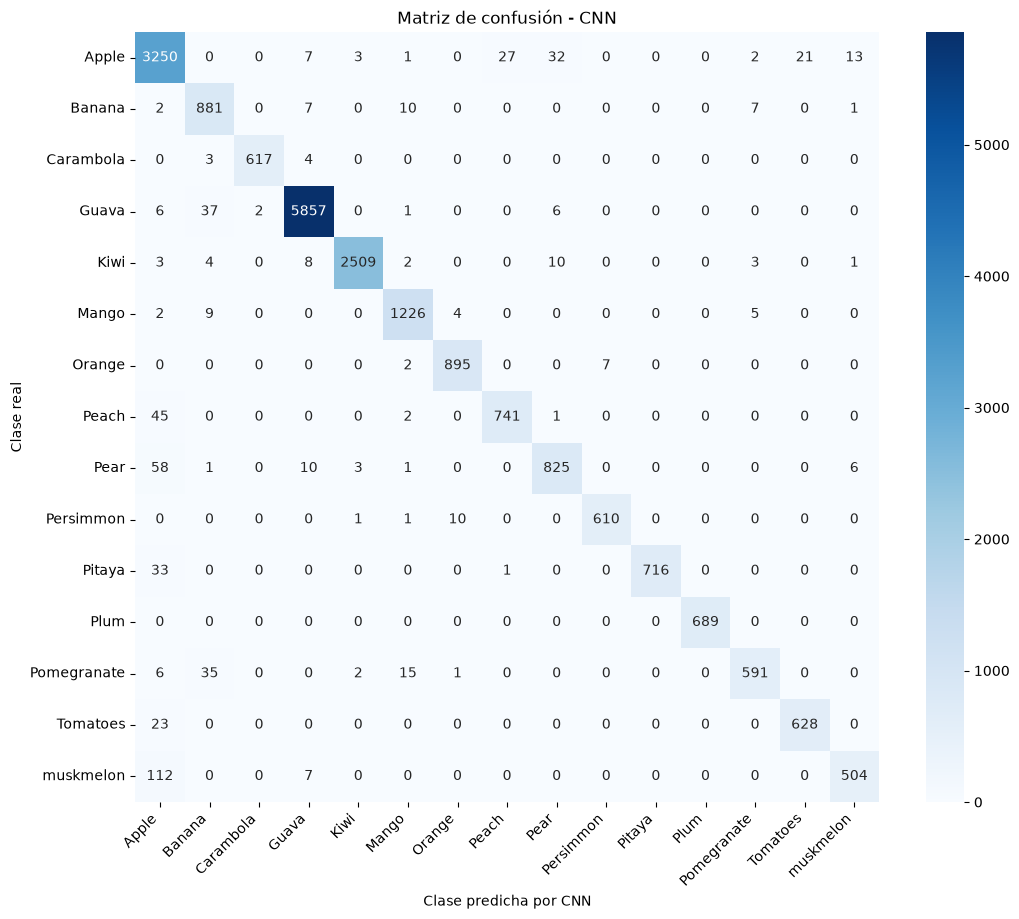

In [75]:
# ==============================
# BLOQUE 13 - Matriz de confusión del modelo SVM
# ==============================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenamos las etiquetas para que la matriz sea estable y fácil de leer
labels = sorted(np.unique(y_true))

# Calculamos la matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Visualizamos la matriz de confusión
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cmap="Blues"
)

plt.xlabel("Clase predicha por CNN")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - CNN")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig("Matriz_confusion_CNN.jpg")
plt.show()

In [ ]:
#codigo en sucio

In [73]:
class_names = label_encoder.classes_

NUM_CLASSES = len(class_names)
print(class_names)

['Apple' 'Banana' 'Carambola' 'Guava' 'Kiwi' 'Mango' 'Orange' 'Peach'
 'Pear' 'Persimmon' 'Pitaya' 'Plum' 'Pomegranate' 'Tomatoes' 'muskmelon']


In [22]:
print(y_batch[:10])

[ 0  7 14  3  7  7  0  3 10  1]


In [16]:
def __len__(self):
    """
    Devuelve el número de batches por época.
    """

    return math.ceil(
        len(self.dataframe) / self.batch_size
    )

In [ ]:
generator.__getitem__(0)

In [15]:
class FruitDataGenerator(Sequence):

    def __init__(
        self,
        dataframe,
        batch_size=32,
        shuffle=True
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.batch_size = batch_size

        self.shuffle = shuffle

        self.on_epoch_end()

        self.image_root = "../../../../archive/"

    def __getitem__(self, index):
        """
        Genera un batch de imágenes y etiquetas.
        """

        # Calcular el primer índice del batch
        inicio = index * self.batch_size

        # Calcular el último índice
        fin = inicio + self.batch_size

        # Obtener únicamente las filas del batch
        batch_data = self.dataframe.iloc[inicio:fin]

        # Crear el batch de imágenes y etiquetas
        X_batch = []
        y_batch = []

        #obtenemos la ruta
        ruta = self.image_root + fila["0"]

    def __len__(self):
        """
        Devuelve el número de batches por época.
        """

        return math.ceil(
            len(self.dataframe) / self.batch_size
        )

In [33]:
#creamos los vectores
X_train = []
y_train = []

#obtenemos rutas
train_paths = "../../../../archive/" + train_df["0"].values
train_labels = train_df["label_encoded"].values


def load_and_preprocess_image(image_path, label):
    """
    Carga una imagen desde disco y la prepara para la CNN.
    """

    # Leer imagen
    imagen = load_img(
        image_path,
        target_size=config_dl.IMAGE_SIZE
    )

    # Convertir a array
    imagen = img_to_array(imagen)

    # Normalizar
    imagen = imagen.astype("float32") / 255.0
    X_train.append(imagen)
    y_train.append(label)

    return X_train, y_train

X_train,y_train=train_dataset.map(load_and_preprocess_image)ale, ale,

TypeError: in user code:

    File "/var/folders/96/vhx0r7sn5wq0jw1ntfplnl_h0000gn/T/ipykernel_98807/4281485668.py", line 16, in load_and_preprocess_image  *
        imagen = load_img(
    File "/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/4_ML_DL/TFM_companeros_estructura/dl_env/lib/python3.12/site-packages/keras/src/utils/image_utils.py", line 250, in load_img  **
        raise TypeError(

    TypeError: path should be path-like or io.BytesIO, not <class 'tensorflow.python.framework.ops.SymbolicTensor'>


In [16]:

print(type(train_paths))
print(train_paths[0])
print(type(train_paths[0]))

<class 'pandas.Series'>


KeyError: 0

In [14]:
#probamos la función
imagen_prueba=load_and_preprocess_image(train_paths(0))
imagen_prueba

TypeError: 'Series' object is not callable

In [18]:
train_dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [16]:
#obtenemos rutas
train_paths = "../../../../archive/" + train_df["0"].values
train_labels = train_df["label_encoded"].values

#creamos dataset de tensor flow
train_dataset = tf.data.Dataset.from_tensor_slices(

    (train_paths, train_labels)

)


def load_and_preprocess_image(image_path, label):
    """
    Carga una imagen desde disco y la prepara para la CNN.
    """

    # Leer imagen
    imagen = load_img(
        image_path,
        target_size=config_dl.IMAGE_SIZE
    )

    # Convertir a array
    imagen = img_to_array(imagen)

    # Normalizar
    imagen = imagen.astype("float32") / 255.0

    return imagen, label

In [12]:
train_paths

7491     ../../../../archive/Apple/Total Number of Appl...
55445              ../../../../archive/Peach/Peach0092.png
48975    ../../../../archive/muskmelon/Muskmelon 00931.png
27743    ../../../../archive/Guava/Guava total/Guava。22...
54259            ../../../../archive/Peach/Peach001990.png
                               ...                        
58657               ../../../../archive/Pear/Pear 1660.png
24297    ../../../../archive/Guava/Guava total/Guava。23...
67461    ../../../../archive/Pomegranate/Pomegranet0049...
28107    ../../../../archive/Guava/Guava total/Guava。63...
50398    ../../../../archive/muskmelon/Muskmelon 00256.png
Name: 0, Length: 49384, dtype: str

In [22]:
train_dataset = train_dataset.map(load_and_preprocess_image)

TypeError: in user code:

    File "/var/folders/96/vhx0r7sn5wq0jw1ntfplnl_h0000gn/T/ipykernel_98807/2805180562.py", line 19, in load_and_preprocess_image  *
        imagen = load_img(
    File "/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/4_ML_DL/TFM_companeros_estructura/dl_env/lib/python3.12/site-packages/keras/src/utils/image_utils.py", line 250, in load_img  **
        raise TypeError(

    TypeError: path should be path-like or io.BytesIO, not <class 'tensorflow.python.framework.ops.SymbolicTensor'>


In [13]:
print(train_df["0"].head())

7491     Apple/Total Number of Apples/Apple 01463.png
55445                             Peach/Peach0092.png
48975                   muskmelon/Muskmelon 00931.png
27743        Guava/Guava total/Guava。2200 resized.png
54259                           Peach/Peach001990.png
Name: 0, dtype: str
